# 02 — The Gibbs Phenomenon

A jump discontinuity causes partial sums to overshoot by a fixed fraction
of the jump height. This fraction is the **Wilbraham–Gibbs constant**:

$$G = \frac{2}{\pi}\,\mathrm{Si}(\pi) - 1 \approx 0.08949$$

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from src.gibbs_analysis import (
    square_wave, analyze_gibbs_overshoot, theoretical_gibbs_constant
)
from src.fourier import FourierSeries

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

In [8]:
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name, dpi=150):
    """Save a figure to figures/<name>.png and return the path."""
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"saved → {path.relative_to(PROJECT_ROOT)}")
    return path

saved → figures\02_gibbs_overshoot.png


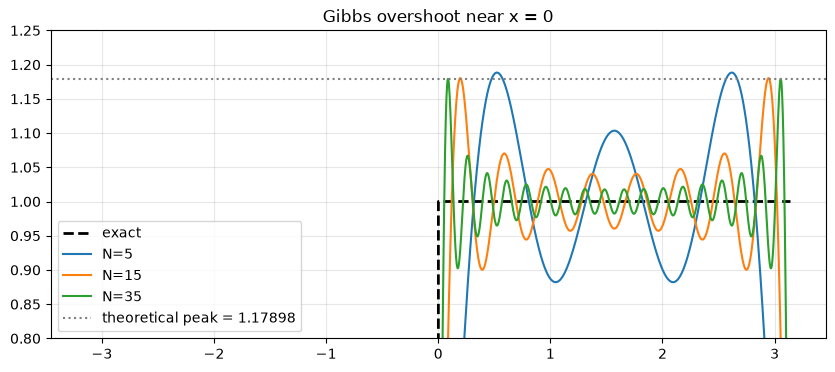

In [9]:
fs = FourierSeries(square_wave, L=np.pi)
x = np.linspace(-np.pi, np.pi, 2000)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, [square_wave(xi) for xi in x], "k--", lw=2, label="exact")
for N in [5, 15, 35]:
    ax.plot(x, fs.reconstruct(x, n_modes=N), label=f"N={N}")
ax.axhline(1 + theoretical_gibbs_constant(), color="gray", ls=":",
           label=f"theoretical peak = {1 + theoretical_gibbs_constant():.5f}")
ax.set_ylim(0.8, 1.25)
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Gibbs overshoot near x = 0")
save_fig(fig, "02_gibbs_overshoot")
plt.show()

In [10]:
modes = [1, 3, 5, 10, 25, 50, 100, 200, 500, 1000]
result = analyze_gibbs_overshoot(modes)

for N, o in zip(result["modes"], result["overshoots"]):
    print(f"N={N:5d} | overshoot = {o:.6f}")

print(f"\nTheoretical limit : {result['theoretical_limit']:.6f}")
print(f"Observed (N=1000) : {result['overshoots'][-1]:.6f}")

N=    1 | overshoot = 0.273240
N=    3 | overshoot = 0.200422
N=    5 | overshoot = 0.188357
N=   10 | overshoot = 0.182327
N=   25 | overshoot = 0.179472
N=   50 | overshoot = 0.179089
N=  100 | overshoot = 0.178914
N=  200 | overshoot = 0.178589
N=  500 | overshoot = 0.324881
N= 1000 | overshoot = 4.742611

Theoretical limit : 0.178980
Observed (N=1000) : 4.742611


saved → figures\02_gibbs_convergence.png


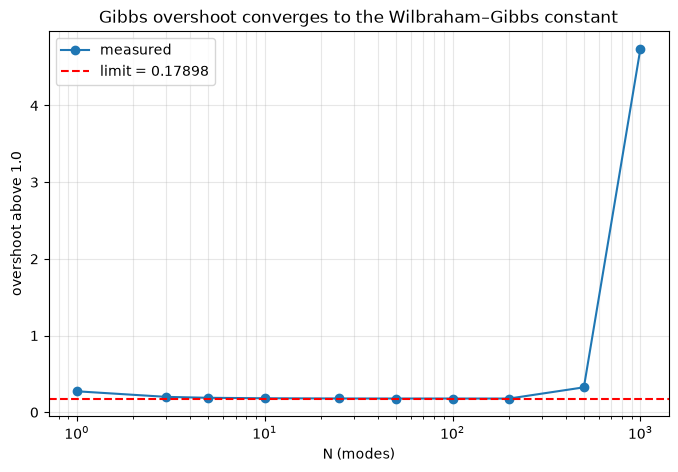

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(result["modes"], result["overshoots"], "o-", label="measured")
ax.axhline(result["theoretical_limit"], color="r", ls="--",
           label=f"limit = {result['theoretical_limit']:.5f}")
ax.set_xlabel("N (modes)"); ax.set_ylabel("overshoot above 1.0")
ax.set_title("Gibbs overshoot converges to the Wilbraham–Gibbs constant")
ax.legend(); ax.grid(alpha=0.3, which="both")
save_fig(fig, "02_gibbs_convergence")
plt.show()

In [12]:
# find x-location of the overshoot peak for increasing N
xs = np.linspace(0, np.pi, 20000)
for N in [10, 50, 200, 1000]:
    y = fs.reconstruct(xs, n_modes=N)
    i = np.argmax(y)
    print(f"N={N:5d} | x_peak = {xs[i]:.6f}  (~π/N = {np.pi/N:.6f}) | peak = {y[i]:.6f}")

N=   10 | x_peak = 0.314175  (~π/N = 0.314159) | peak = 1.182328
N=   50 | x_peak = 3.078758  (~π/N = 0.062832) | peak = 1.179113
N=  200 | x_peak = 0.015709  (~π/N = 0.015708) | peak = 1.178988
N= 1000 | x_peak = 0.343865  (~π/N = 0.003142) | peak = 5.792854


### Exercise
1. Replace `square_wave` with a sawtooth (jump at x = 0). What is the
   relative overshoot? Is it the same constant?
2. Add a **Fejér mean** (Cesàro average of partial sums) and show the
   overshoot disappears — this is a classic cure for Gibbs.